# Buzzhive Feature Engineering

This notebook builds the audio preprocessing and feature extraction pipeline:
1. Audio loading and preprocessing
2. Mel-spectrogram extraction
3. MFCC feature extraction
4. Data augmentation strategies
5. Dataset preparation for model training


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import torch
import torchaudio
import torchaudio.transforms as T
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Paths
DATA_DIR = Path('../archive')
AUDIO_DIR = DATA_DIR / 'sound_files' / 'sound_files'
OUTPUT_DIR = Path('../outputs')
PROCESSED_DIR = OUTPUT_DIR / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Load processed metadata from exploration notebook
df = pd.read_csv(OUTPUT_DIR / 'processed_metadata.csv')
print(f"Loaded {len(df)} records with audio")


Loaded 1222 records with audio


## 1. Audio Preprocessing Configuration


In [2]:
# Audio preprocessing configuration
class AudioConfig:
    """Configuration for audio preprocessing."""
    # Sampling
    SAMPLE_RATE = 22050  # Target sample rate (Hz)
    DURATION = 10.0      # Target duration per segment (seconds)
    
    # Mel-spectrogram parameters
    N_MELS = 128         # Number of mel bands
    N_FFT = 2048         # FFT window size
    HOP_LENGTH = 512     # Hop length between frames
    FMIN = 20            # Minimum frequency
    FMAX = 8000          # Maximum frequency (bee sounds mostly < 8kHz)
    
    # MFCC parameters
    N_MFCC = 13          # Number of MFCCs
    
    # Pre-emphasis
    PRE_EMPHASIS = 0.97  # Pre-emphasis filter coefficient
    
    # Computed values
    @property
    def n_samples(self):
        return int(self.SAMPLE_RATE * self.DURATION)
    
    @property
    def mel_time_steps(self):
        return int(np.ceil(self.n_samples / self.HOP_LENGTH))

config = AudioConfig()
print(f"Target samples per audio: {config.n_samples}")
print(f"Mel-spectrogram shape: ({config.N_MELS}, ~{config.mel_time_steps})")


Target samples per audio: 220500
Mel-spectrogram shape: (128, ~431)


## 2. Audio Loading and Preprocessing Functions


In [3]:
def load_audio(file_path, target_sr=22050, duration=None):
    """
    Load audio file and resample to target sample rate.
    
    Args:
        file_path: Path to audio file
        target_sr: Target sample rate
        duration: Max duration in seconds (None for full audio)
    
    Returns:
        waveform: numpy array of audio samples
        sr: sample rate
    """
    y, sr = librosa.load(file_path, sr=target_sr, duration=duration, mono=True)
    return y, sr


def apply_pre_emphasis(y, coef=0.97):
    """
    Apply pre-emphasis filter to boost high frequencies.
    This helps capture subtle bee buzzing sounds in higher frequency ranges.
    
    Args:
        y: Audio waveform
        coef: Pre-emphasis coefficient (0.95-0.97 typical)
    
    Returns:
        Pre-emphasized waveform
    """
    return np.append(y[0], y[1:] - coef * y[:-1])


def normalize_audio(y):
    """Normalize audio to [-1, 1] range."""
    max_val = np.abs(y).max()
    if max_val > 0:
        y = y / max_val
    return y


def pad_or_truncate(y, target_length):
    """
    Pad or truncate audio to target length.
    
    Args:
        y: Audio waveform
        target_length: Target number of samples
    
    Returns:
        Audio of exactly target_length samples
    """
    if len(y) > target_length:
        # Truncate from center
        start = (len(y) - target_length) // 2
        y = y[start:start + target_length]
    elif len(y) < target_length:
        # Pad with zeros
        pad_left = (target_length - len(y)) // 2
        pad_right = target_length - len(y) - pad_left
        y = np.pad(y, (pad_left, pad_right), mode='constant')
    return y


def preprocess_audio(file_path, config):
    """
    Full preprocessing pipeline for a single audio file.
    
    Args:
        file_path: Path to audio file
        config: AudioConfig instance
    
    Returns:
        Preprocessed audio waveform
    """
    # Load audio
    y, sr = load_audio(file_path, target_sr=config.SAMPLE_RATE)
    
    # Apply pre-emphasis
    y = apply_pre_emphasis(y, config.PRE_EMPHASIS)
    
    # Normalize
    y = normalize_audio(y)
    
    # Pad or truncate to target length
    y = pad_or_truncate(y, config.n_samples)
    
    return y


# Test the preprocessing pipeline
test_file = list(AUDIO_DIR.glob('*.wav'))[0]
y_processed = preprocess_audio(test_file, config)
print(f"Preprocessed audio shape: {y_processed.shape}")
print(f"Audio range: [{y_processed.min():.3f}, {y_processed.max():.3f}]")


Preprocessed audio shape: (220500,)
Audio range: [-0.664, 0.815]


In [4]:
def extract_melspectrogram(y, config, to_db=True):
    """
    Extract mel-spectrogram from audio waveform.
    
    Args:
        y: Audio waveform
        config: AudioConfig instance
        to_db: Convert to decibel scale
    
    Returns:
        Mel-spectrogram array of shape (n_mels, time_steps)
    """
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=config.SAMPLE_RATE,
        n_fft=config.N_FFT,
        hop_length=config.HOP_LENGTH,
        n_mels=config.N_MELS,
        fmin=config.FMIN,
        fmax=config.FMAX
    )
    
    if to_db:
        mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    
    return mel_spec


def extract_mfcc(y, config, include_deltas=True):
    """
    Extract MFCCs from audio waveform.
    
    Args:
        y: Audio waveform
        config: AudioConfig instance
        include_deltas: Whether to include delta and delta-delta features
    
    Returns:
        MFCC array of shape (n_mfcc * 3, time_steps) if include_deltas else (n_mfcc, time_steps)
    """
    mfccs = librosa.feature.mfcc(
        y=y,
        sr=config.SAMPLE_RATE,
        n_mfcc=config.N_MFCC,
        n_fft=config.N_FFT,
        hop_length=config.HOP_LENGTH
    )
    
    if include_deltas:
        delta_mfccs = librosa.feature.delta(mfccs)
        delta2_mfccs = librosa.feature.delta(mfccs, order=2)
        mfccs = np.vstack([mfccs, delta_mfccs, delta2_mfccs])
    
    return mfccs


def extract_all_features(y, config):
    """
    Extract all audio features from waveform.
    
    Args:
        y: Audio waveform
        config: AudioConfig instance
    
    Returns:
        Dictionary with mel_spec and mfcc features
    """
    mel_spec = extract_melspectrogram(y, config)
    mfccs = extract_mfcc(y, config)
    
    return {
        'mel_spec': mel_spec,
        'mfcc': mfccs
    }


# Test feature extraction
features = extract_all_features(y_processed, config)
print(f"Mel-spectrogram shape: {features['mel_spec'].shape}")
print(f"MFCC shape (with deltas): {features['mfcc'].shape}")


Mel-spectrogram shape: (128, 431)
MFCC shape (with deltas): (39, 431)


## 4. Data Augmentation


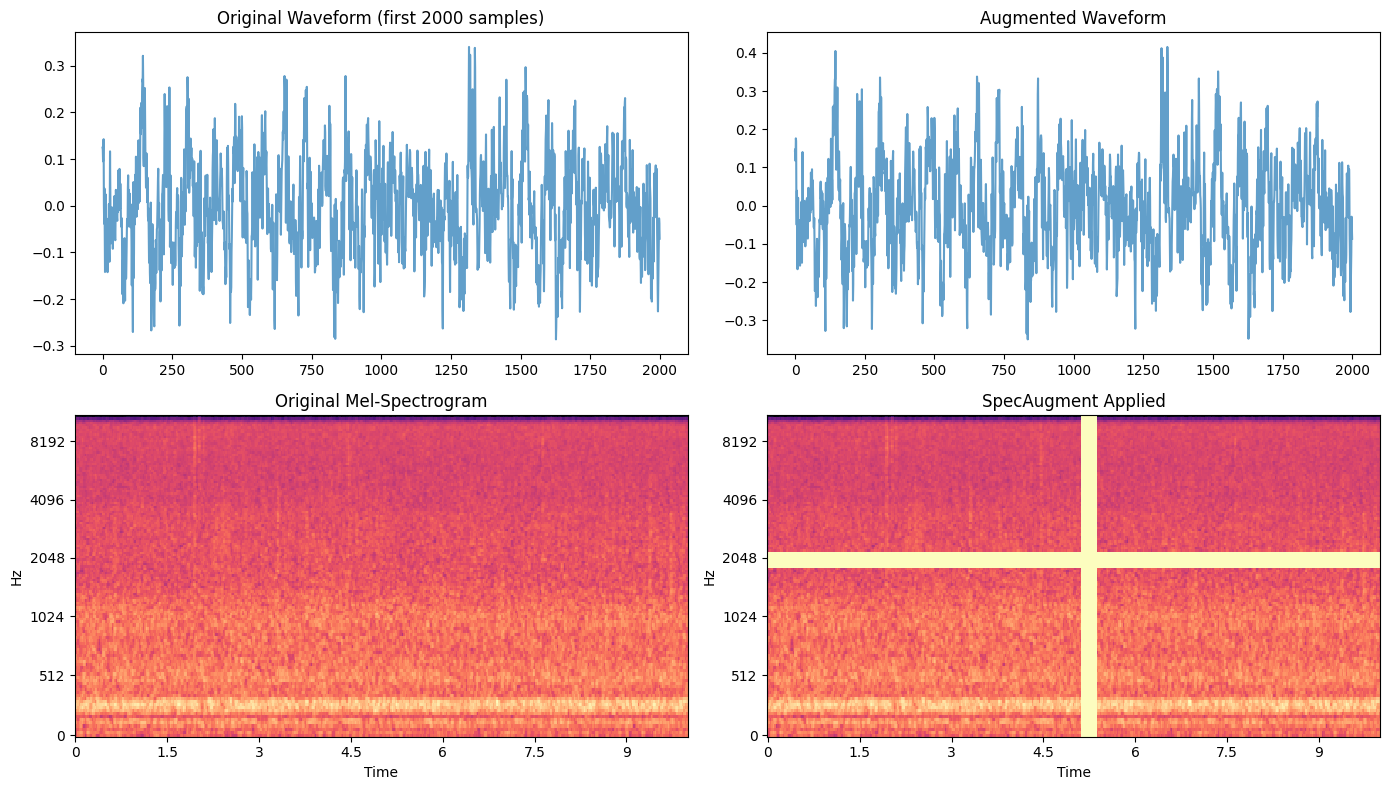

In [5]:
class AudioAugmenter:
    """Audio data augmentation for beehive sounds."""
    
    def __init__(self, config):
        self.config = config
    
    def add_noise(self, y, noise_factor=0.005):
        """Add random Gaussian noise."""
        noise = np.random.randn(len(y))
        return y + noise_factor * noise
    
    def time_shift(self, y, shift_max=0.2):
        """Shift audio in time (circular shift)."""
        shift = int(np.random.uniform(-shift_max, shift_max) * len(y))
        return np.roll(y, shift)
    
    def pitch_shift(self, y, n_steps_range=(-2, 2)):
        """Shift pitch up or down."""
        n_steps = np.random.uniform(*n_steps_range)
        return librosa.effects.pitch_shift(y, sr=self.config.SAMPLE_RATE, n_steps=n_steps)
    
    def time_stretch(self, y, rate_range=(0.9, 1.1)):
        """Stretch or compress audio in time."""
        rate = np.random.uniform(*rate_range)
        y_stretched = librosa.effects.time_stretch(y, rate=rate)
        # Ensure same length
        return pad_or_truncate(y_stretched, len(y))
    
    def apply_random_augmentation(self, y, p=0.5):
        """Apply random augmentations with probability p."""
        if np.random.random() < p:
            y = self.add_noise(y)
        if np.random.random() < p:
            y = self.time_shift(y)
        # Pitch and time stretch are more expensive, apply less often
        if np.random.random() < p * 0.5:
            y = self.pitch_shift(y)
        return normalize_audio(y)


class SpecAugment:
    """SpecAugment: Augmentation for mel-spectrograms."""
    
    def __init__(self, freq_mask_param=15, time_mask_param=35, n_freq_masks=2, n_time_masks=2):
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.n_freq_masks = n_freq_masks
        self.n_time_masks = n_time_masks
    
    def freq_mask(self, spec, mask_value=0):
        """Apply frequency masking."""
        spec = spec.copy()
        n_mels, n_time = spec.shape
        
        for _ in range(self.n_freq_masks):
            f = np.random.randint(0, self.freq_mask_param)
            f0 = np.random.randint(0, n_mels - f)
            spec[f0:f0 + f, :] = mask_value
        
        return spec
    
    def time_mask(self, spec, mask_value=0):
        """Apply time masking."""
        spec = spec.copy()
        n_mels, n_time = spec.shape
        
        for _ in range(self.n_time_masks):
            t = np.random.randint(0, min(self.time_mask_param, n_time))
            t0 = np.random.randint(0, n_time - t)
            spec[:, t0:t0 + t] = mask_value
        
        return spec
    
    def __call__(self, spec):
        """Apply both frequency and time masking."""
        spec = self.freq_mask(spec)
        spec = self.time_mask(spec)
        return spec


# Test augmentations
augmenter = AudioAugmenter(config)
spec_augment = SpecAugment()

# Apply augmentations
y_aug = augmenter.apply_random_augmentation(y_processed)
mel_aug = spec_augment(features['mel_spec'])

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(y_processed[:2000], alpha=0.7)
axes[0, 0].set_title('Original Waveform (first 2000 samples)')

axes[0, 1].plot(y_aug[:2000], alpha=0.7)
axes[0, 1].set_title('Augmented Waveform')

librosa.display.specshow(features['mel_spec'], ax=axes[1, 0], x_axis='time', y_axis='mel',
                         sr=config.SAMPLE_RATE, hop_length=config.HOP_LENGTH)
axes[1, 0].set_title('Original Mel-Spectrogram')

librosa.display.specshow(mel_aug, ax=axes[1, 1], x_axis='time', y_axis='mel',
                         sr=config.SAMPLE_RATE, hop_length=config.HOP_LENGTH)
axes[1, 1].set_title('SpecAugment Applied')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'augmentation_example.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Dataset Preparation


In [6]:
def find_audio_files_for_row(row, audio_dir):
    """Find all segment WAV files corresponding to a CSV row."""
    base_name = row['file name'].replace('.raw', '')
    pattern = f"{base_name}__segment*.wav"
    matches = list(audio_dir.glob(pattern))
    return sorted(matches)


def create_dataset_records(df, audio_dir, config, use_segments='all'):
    """
    Create dataset records linking audio files to labels.
    
    Args:
        df: DataFrame with metadata
        audio_dir: Path to audio files
        config: AudioConfig instance
        use_segments: 'all' for all segments, 'first' for first only, or int for specific segment
    
    Returns:
        List of dictionaries with file paths and labels
    """
    records = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Creating dataset records"):
        audio_files = find_audio_files_for_row(row, audio_dir)
        
        if not audio_files:
            continue
        
        # Select segments
        if use_segments == 'all':
            files_to_use = audio_files
        elif use_segments == 'first':
            files_to_use = audio_files[:1]
        elif isinstance(use_segments, int):
            files_to_use = [f for f in audio_files if f'segment{use_segments}' in f.name]
        else:
            files_to_use = audio_files
        
        for audio_file in files_to_use:
            records.append({
                'audio_path': str(audio_file),
                'queen_status': row['queen status'],
                'queen_presence': row['queen presence'],
                'hive_number': row['hive number'],
                'device': row['device'],
                'datetime': row['date'],
                'hive_temp': row['hive temp'],
                'hive_humidity': row['hive humidity']
            })
    
    return records


# Create dataset records using all segments
dataset_records = create_dataset_records(df, AUDIO_DIR, config, use_segments='all')
print(f"Total dataset records: {len(dataset_records)}")



Creating dataset records:   0%|          | 0/1222 [00:00<?, ?it/s]


Creating dataset records:   2%|▏         | 24/1222 [00:00<00:05, 238.72it/s]


Creating dataset records:   4%|▍         | 50/1222 [00:00<00:04, 247.67it/s]


Creating dataset records:   6%|▌         | 76/1222 [00:00<00:04, 250.70it/s]


Creating dataset records:   8%|▊         | 102/1222 [00:00<00:04, 251.77it/s]

...


Creating dataset records:  95%|█████████▌| 1164/1222 [00:04<00:00, 251.58it/s]


Creating dataset records:  97%|█████████▋| 1190/1222 [00:04<00:00, 251.02it/s]


Creating dataset records: 100%|█████████▉| 1216/1222 [00:04<00:00, 250.36it/s]


Creating dataset records: 100%|██████████| 1222/1222 [00:04<00:00, 250.53it/s]

Total dataset records: 7100


In [7]:
# Convert to DataFrame for easier manipulation
dataset_df = pd.DataFrame(dataset_records)

# Label distribution
print("Label distribution in full dataset:")
print(dataset_df['queen_status'].value_counts().sort_index())

# Class mapping
CLASS_NAMES = {
    0: 'Queenright',
    1: 'Queenless', 
    2: 'Queen_New',
    3: 'Queen_Accepted'
}

dataset_df['class_name'] = dataset_df['queen_status'].map(CLASS_NAMES)
print("\nClass names:")
print(dataset_df['class_name'].value_counts())


Label distribution in full dataset:
queen_status
0    1038
1     946
2    1553
3    3563
Name: count, dtype: int64

Class names:
class_name
Queen_Accepted    3563
Queen_New         1553
Queenright        1038
Queenless          946
Name: count, dtype: int64


## 6. Train/Validation/Test Split (by Hive)


In [8]:
# STRATIFIED SPLIT WITHIN EACH HIVE
# This ensures similar class distribution across train/val/test
# while keeping segments from same recording together

from sklearn.model_selection import train_test_split

hives = dataset_df['hive_number'].unique()
print(f"Unique hives: {hives}")

# Check original class distribution
print("\nOverall class distribution:")
print(dataset_df['queen_status'].value_counts().sort_index())

# Split each hive's data stratified by class, then combine
all_train, all_val, all_test = [], [], []

for hive in sorted(hives):
    hive_data = dataset_df[dataset_df['hive_number'] == hive].copy()
    print(f"\nHive {hive}: {len(hive_data)} samples")
    
    # Check if we have enough samples per class for stratification
    class_counts = hive_data['queen_status'].value_counts()
    min_count = class_counts.min()
    
    if min_count >= 3:  # Need at least 3 for stratified split
        # Stratified split: 70% train, 10% val, 20% test
        train_val, test = train_test_split(
            hive_data, test_size=0.2, 
            stratify=hive_data['queen_status'], random_state=42
        )
        train, val = train_test_split(
            train_val, test_size=0.125,  # 0.125 of 0.8 = 0.1 overall
            stratify=train_val['queen_status'], random_state=42
        )
    else:
        # Not enough samples - use random split
        print(f"  Warning: Small class counts, using random split")
        train_val, test = train_test_split(hive_data, test_size=0.2, random_state=42)
        train, val = train_test_split(train_val, test_size=0.125, random_state=42)
    
    all_train.append(train)
    all_val.append(val)
    all_test.append(test)
    print(f"  Split: train={len(train)}, val={len(val)}, test={len(test)}")

# Combine all hives
train_df = pd.concat(all_train, ignore_index=True)
val_df = pd.concat(all_val, ignore_index=True)
test_df = pd.concat(all_test, ignore_index=True)

print(f"\n{'='*50}")
print(f"FINAL DATASET SPLITS:")
print(f"{'='*50}")
print(f"  Train: {len(train_df)} samples ({len(train_df)/len(dataset_df)*100:.1f}%)")
print(f"  Val:   {len(val_df)} samples ({len(val_df)/len(dataset_df)*100:.1f}%)")
print(f"  Test:  {len(test_df)} samples ({len(test_df)/len(dataset_df)*100:.1f}%)")

# Verify class distribution is similar across splits
print(f"\nClass distribution verification:")
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = df['queen_status'].value_counts(normalize=True).sort_index()
    print(f"  {name}: " + ", ".join([f"class {i}: {v:.1%}" for i, v in dist.items()]))


Unique hives: [5 3 4 1]

Overall class distribution:
queen_status
0    1038
1     946
2    1553
3    3563
Name: count, dtype: int64

Hive 1: 2843 samples
  Split: train=1989, val=285, test=569

Hive 3: 1130 samples
  Split: train=791, val=113, test=226

Hive 4: 2546 samples
  Split: train=1781, val=255, test=510

Hive 5: 581 samples
  Split: train=406, val=58, test=117

FINAL DATASET SPLITS:
  Train: 4967 samples (70.0%)
  Val:   711 samples (10.0%)
  Test:  1422 samples (20.0%)

Class distribution verification:
  Train: class 0: 14.6%, class 1: 13.3%, class 2: 21.9%, class 3: 50.2%
  Val: class 0: 14.5%, class 1: 13.4%, class 2: 21.9%, class 3: 50.2%
  Test: class 0: 14.7%, class 1: 13.4%, class 2: 21.8%, class 3: 50.1%


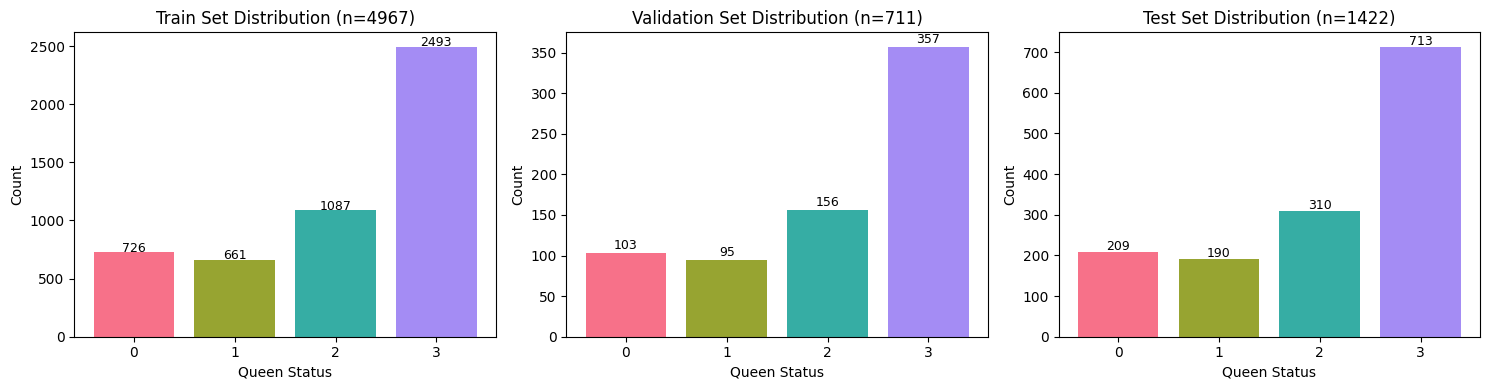

In [9]:
# Check class distribution in each split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, split_df) in zip(axes, [('Train', train_df), ('Validation', val_df), ('Test', test_df)]):
    counts = split_df['queen_status'].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=sns.color_palette('husl', len(counts)))
    ax.set_title(f'{name} Set Distribution (n={len(split_df)})')
    ax.set_xlabel('Queen Status')
    ax.set_ylabel('Count')
    ax.set_xticks(counts.index)
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                f'{count}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. PyTorch Dataset Class


In [10]:
from torch.utils.data import Dataset, DataLoader

class BeehiveAudioDataset(Dataset):
    """PyTorch Dataset for beehive audio classification."""
    
    def __init__(self, df, config, augment=False, spec_augment=False):
        """
        Args:
            df: DataFrame with audio_path and queen_status columns
            config: AudioConfig instance
            augment: Whether to apply audio augmentation
            spec_augment: Whether to apply SpecAugment
        """
        self.df = df.reset_index(drop=True)
        self.config = config
        self.augment = augment
        self.spec_augment_flag = spec_augment
        
        self.audio_augmenter = AudioAugmenter(config) if augment else None
        self.spec_augmenter = SpecAugment() if spec_augment else None
        
        # Label encoder
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.df['queen_status'].values)
        self.num_classes = len(self.label_encoder.classes_)
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = row['audio_path']
        label = self.labels[idx]
        
        # Load and preprocess audio
        y = preprocess_audio(audio_path, self.config)
        
        # Apply audio augmentation
        if self.augment and self.audio_augmenter:
            y = self.audio_augmenter.apply_random_augmentation(y)
        
        # Extract mel-spectrogram
        mel_spec = extract_melspectrogram(y, self.config)
        
        # Apply SpecAugment
        if self.spec_augment_flag and self.spec_augmenter:
            mel_spec = self.spec_augmenter(mel_spec)
        
        # Convert to tensor
        mel_spec = torch.FloatTensor(mel_spec).unsqueeze(0)  # Add channel dimension
        label = torch.LongTensor([label]).squeeze()
        
        return mel_spec, label
    
    def get_class_weights(self):
        """Calculate class weights for imbalanced data."""
        class_counts = np.bincount(self.labels)
        weights = 1.0 / class_counts
        weights = weights / weights.sum() * len(class_counts)
        return torch.FloatTensor(weights)


# Create datasets
train_dataset = BeehiveAudioDataset(train_df, config, augment=True, spec_augment=True)
val_dataset = BeehiveAudioDataset(val_df, config, augment=False, spec_augment=False)
test_dataset = BeehiveAudioDataset(test_df, config, augment=False, spec_augment=False)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset: {len(val_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")
print(f"Number of classes: {train_dataset.num_classes}")
print(f"Class weights: {train_dataset.get_class_weights()}")


Train dataset: 4967 samples
Val dataset: 711 samples
Test dataset: 1422 samples
Number of classes: 4
Class weights: tensor([1.3083, 1.4369, 0.8738, 0.3810])


Sample mel-spectrogram shape: torch.Size([1, 128, 431])
Sample label: 0 (Queenright)


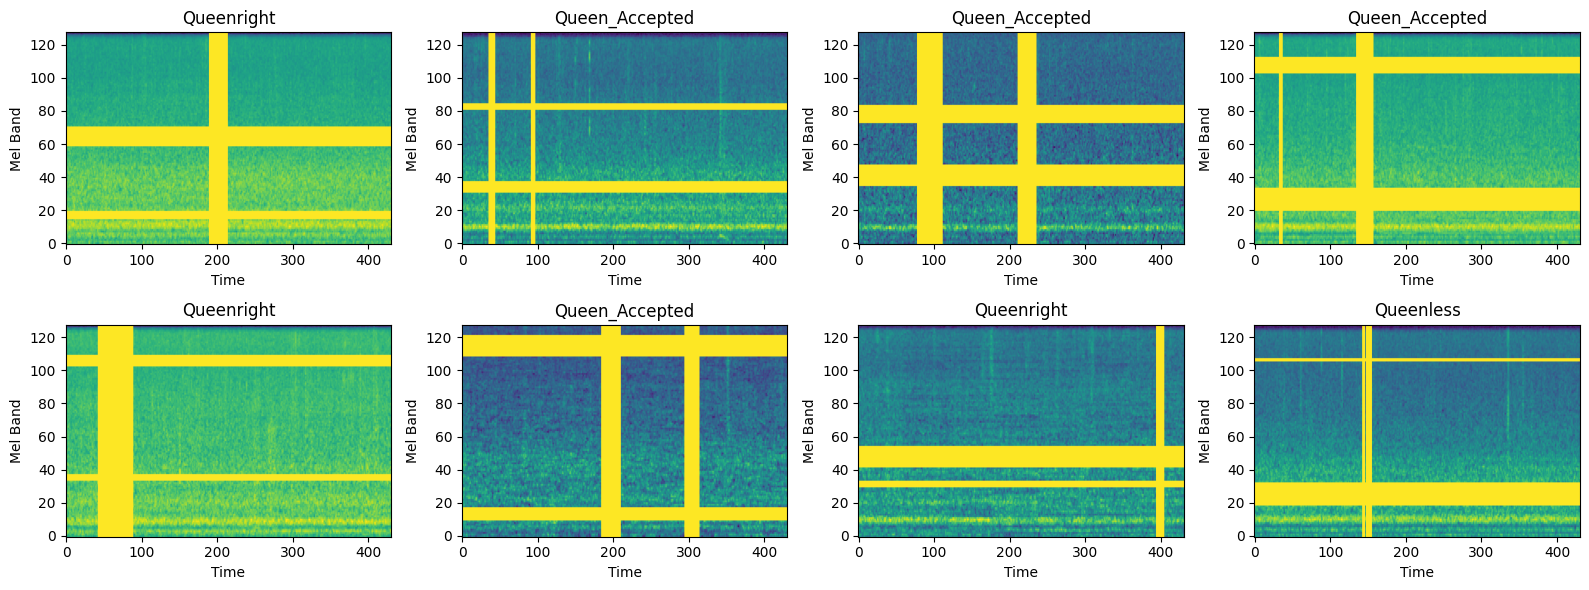

In [11]:
# Test the dataset
sample_mel, sample_label = train_dataset[0]
print(f"Sample mel-spectrogram shape: {sample_mel.shape}")
print(f"Sample label: {sample_label.item()} ({CLASS_NAMES[sample_label.item()]})")

# Visualize a batch
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i in range(8):
    ax = axes[i // 4, i % 4]
    mel, label = train_dataset[i * 100]  # Sample from different parts
    ax.imshow(mel.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(f'{CLASS_NAMES[label.item()]}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Mel Band')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Save Processed Data and Configuration


In [12]:
# Save the train/val/test splits
train_df.to_csv(PROCESSED_DIR / 'train_split.csv', index=False)
val_df.to_csv(PROCESSED_DIR / 'val_split.csv', index=False)
test_df.to_csv(PROCESSED_DIR / 'test_split.csv', index=False)

print(f"Saved splits to {PROCESSED_DIR}")

# Save configuration
config_dict = {
    'sample_rate': config.SAMPLE_RATE,
    'duration': config.DURATION,
    'n_mels': config.N_MELS,
    'n_fft': config.N_FFT,
    'hop_length': config.HOP_LENGTH,
    'fmin': config.FMIN,
    'fmax': config.FMAX,
    'n_mfcc': config.N_MFCC,
    'pre_emphasis': config.PRE_EMPHASIS,
    'class_names': CLASS_NAMES,
    'num_classes': len(CLASS_NAMES)
}

import json
with open(PROCESSED_DIR / 'config.json', 'w') as f:
    json.dump(config_dict, f, indent=2)

print(f"Saved configuration to {PROCESSED_DIR / 'config.json'}")


Saved splits to ../outputs/processed
Saved configuration to ../outputs/processed/config.json


In [13]:
print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print(f"\nAudio Configuration:")
print(f"  Sample rate: {config.SAMPLE_RATE} Hz")
print(f"  Duration: {config.DURATION}s")
print(f"  Samples per audio: {config.n_samples}")

print(f"\nFeature Dimensions:")
print(f"  Mel-spectrogram: ({config.N_MELS}, {config.mel_time_steps})")
print(f"  MFCCs (with deltas): ({config.N_MFCC * 3}, {config.mel_time_steps})")

print(f"\nDataset Sizes:")
print(f"  Train: {len(train_df)}")
print(f"  Validation: {len(val_df)}")
print(f"  Test: {len(test_df)}")

print(f"\nClass Weights (for imbalanced training):")
for i, w in enumerate(train_dataset.get_class_weights()):
    print(f"  {CLASS_NAMES[i]}: {w:.3f}")

print(f"\nSaved files:")
print(f"  {PROCESSED_DIR / 'train_split.csv'}")
print(f"  {PROCESSED_DIR / 'val_split.csv'}")
print(f"  {PROCESSED_DIR / 'test_split.csv'}")
print(f"  {PROCESSED_DIR / 'config.json'}")


FEATURE ENGINEERING SUMMARY

Audio Configuration:
  Sample rate: 22050 Hz
  Duration: 10.0s
  Samples per audio: 220500

Feature Dimensions:
  Mel-spectrogram: (128, 431)
  MFCCs (with deltas): (39, 431)

Dataset Sizes:
  Train: 4967
  Validation: 711
  Test: 1422

Class Weights (for imbalanced training):
  Queenright: 1.308
  Queenless: 1.437
  Queen_New: 0.874
  Queen_Accepted: 0.381

Saved files:
  ../outputs/processed/train_split.csv
  ../outputs/processed/val_split.csv
  ../outputs/processed/test_split.csv
  ../outputs/processed/config.json


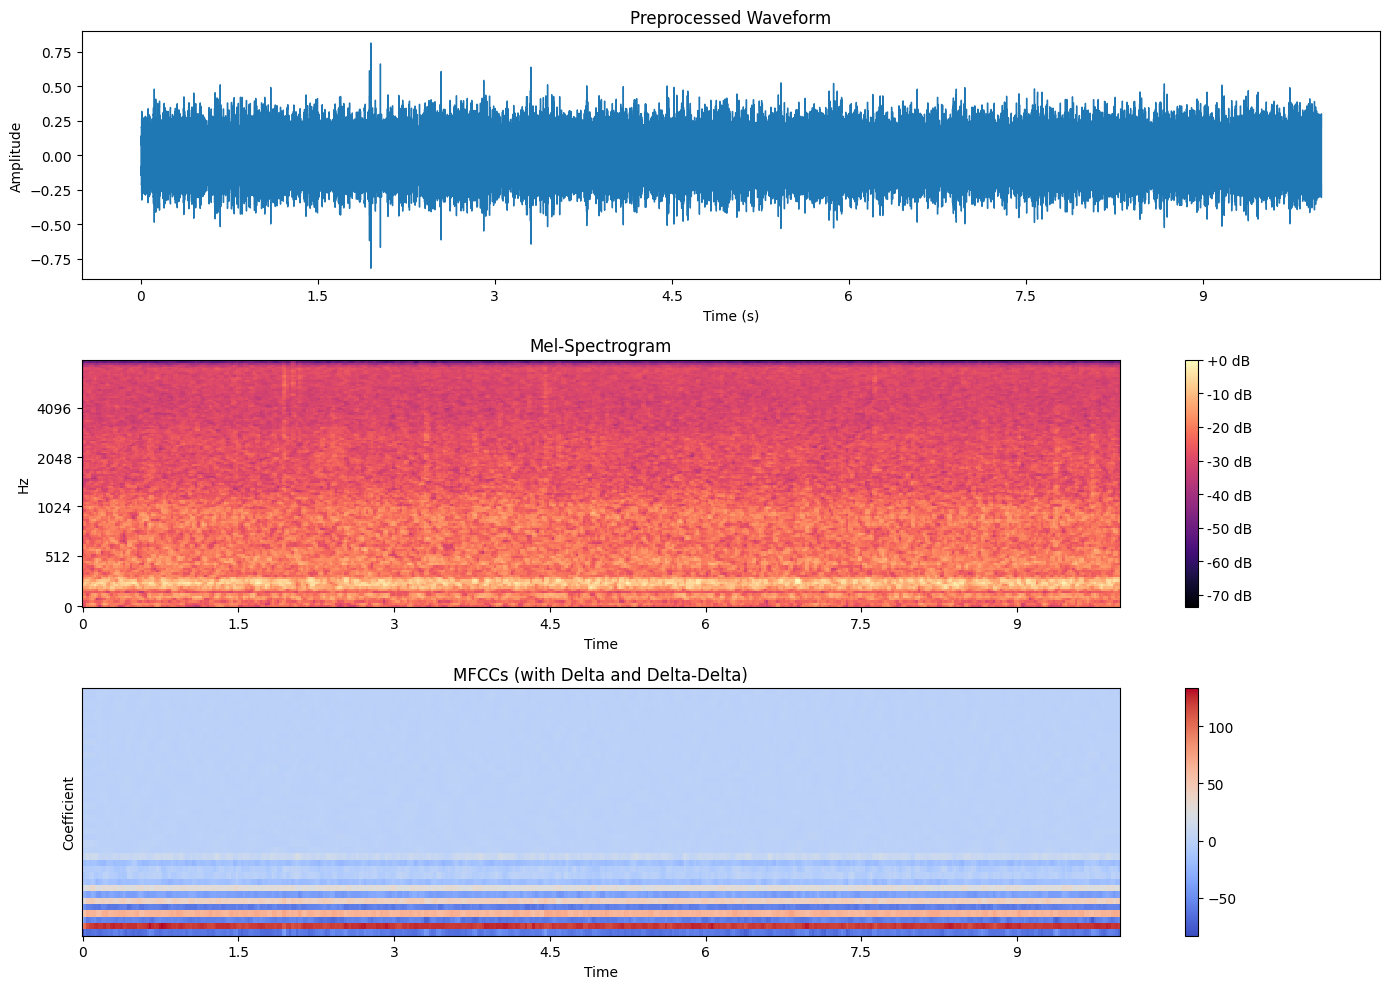

In [14]:
# Visualize extracted features
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Waveform
ax1 = axes[0]
librosa.display.waveshow(y_processed, sr=config.SAMPLE_RATE, ax=ax1)
ax1.set_title('Preprocessed Waveform')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')

# Mel-spectrogram
ax2 = axes[1]
img = librosa.display.specshow(
    features['mel_spec'], 
    x_axis='time', 
    y_axis='mel',
    sr=config.SAMPLE_RATE,
    hop_length=config.HOP_LENGTH,
    fmax=config.FMAX,
    ax=ax2
)
ax2.set_title('Mel-Spectrogram')
fig.colorbar(img, ax=ax2, format='%+2.0f dB')

# MFCCs
ax3 = axes[2]
img = librosa.display.specshow(
    features['mfcc'],
    x_axis='time',
    sr=config.SAMPLE_RATE,
    hop_length=config.HOP_LENGTH,
    ax=ax3
)
ax3.set_title('MFCCs (with Delta and Delta-Delta)')
ax3.set_ylabel('Coefficient')
fig.colorbar(img, ax=ax3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_extraction_example.png', dpi=150, bbox_inches='tight')
plt.show()
